In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score)
import time
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

In [ ]:


column_names = ['height', 'length', 'area', 'eccen', 'p_black', 
                'p_and', 'mean_tr', 'blackpix', 'blackand', 'wb_trans', 'class']

# data is separated by one or more whitespace
page_data = pd.read_csv('data/raw/page-blocks.data', sep='\s+', names=column_names)

print(f"Dataset shape: {page_data.shape}")
page_data.head()

Dataset shape: (5473, 11)


,height,length,area,eccen,p_black,p_and,mean_tr,blackpix,blackand,wb_trans,class
0,5,7,35,1.400,0.400,0.657,2.33,14,23,6,1
1,6,7,42,1.167,0.429,0.881,3.60,18,37,5,1
2,6,18,108,3.000,0.287,0.741,4.43,31,80,7,1
3,5,7,35,1.400,0.371,0.743,4.33,13,26,3,1
4,6,3,18,0.500,0.500,0.944,2.25,9,17,4,1


In [6]:
print("Dataset Info:")
print(page_data.info())
print("\nClass distribution:")
print(page_data['class'].value_counts().sort_index())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 5473 entries, 0 to 5472
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   height    5473 non-null   int64  
 1   length    5473 non-null   int64  
 2   area      5473 non-null   int64  
 3   eccen     5473 non-null   float64
 4   p_black   5473 non-null   float64
 5   p_and     5473 non-null   float64
 6   mean_tr   5473 non-null   float64
 7   blackpix  5473 non-null   int64  
 8   blackand  5473 non-null   int64  
 9   wb_trans  5473 non-null   int64  
 10  class     5473 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 470.5 KB
None

Class distribution:
class
1    4913
2     329
3      28
4      88
5     115
Name: count, dtype: int64


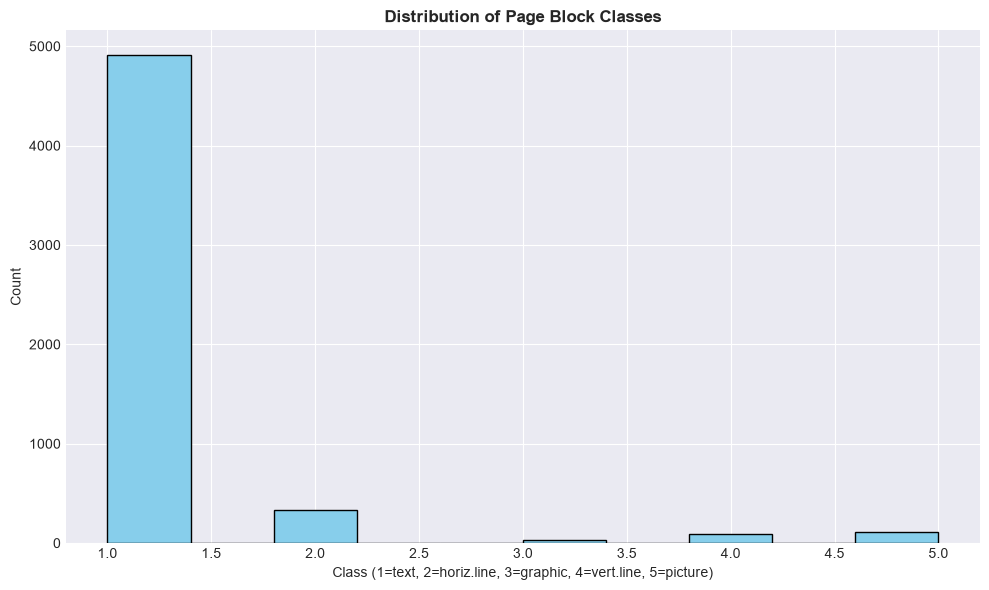

In [9]:
# Visualize class distribution
plt.figure(figsize=(10, 6))
plt.hist(page_data['class'],color='skyblue',edgecolor='black')
plt.title('Distribution of Page Block Classes', fontweight='bold')
plt.xlabel('Class (1=text, 2=horiz.line, 3=graphic, 4=vert.line, 5=picture)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()

In [10]:
# For simpler binary classification, combine classes
# Class 1 (text) vs Non-text (classes 2-5)
page_data['binary_class']=(page_data['class']==1).astype(int)
print("Binary class distribution:")
print(page_data['binary_class'].value_counts())

Binary class distribution:
binary_class
1    4913
0     560
Name: count, dtype: int64


In [11]:
# Separate features and target
X=page_data.drop(columns=['class','binary_class'])
y=page_data['binary_class']


print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (5473, 10)
Target shape: (5473,)


In [12]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (CRITICAL for SVM and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 4378
Test set size: 1095


In [13]:
# SVM with Linear Kernel
print("Training SVM with Linear Kernel...")
start_time = time.time()

svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)
acc_linear = accuracy_score(y_test, y_pred_linear)

print(f"Training time: {time.time() - start_time:.2f} seconds")
print(f"Accuracy: {acc_linear:.4f}")


Training SVM with Linear Kernel...
Training time: 0.14 seconds
Accuracy: 0.9653


In [14]:
# SVM with RBF Kernel
print("Training SVM with RBF Kernel...")
start_time = time.time()

svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)
acc_rbf = accuracy_score(y_test, y_pred_rbf)

print(f"Training time: {time.time() - start_time:.2f} seconds")
print(f"Accuracy: {acc_rbf:.4f}")

Training SVM with RBF Kernel...
Training time: 0.12 seconds
Accuracy: 0.9753


In [ ]:
# Hyperparameter Tuning for SVM
print("Performing Grid Search for SVM...")

# C controls how much SVM cares about classification errors vs. a wider margin.(act like penalty for wrong classification )
# gamma controls how far the influence of each training point reaches when using the RBF kernel
# Grid Search will not compare different kernels. It only tunes C and gamma for RBF.
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.001, 0.01],
    'kernel': ['rbf']
}

# GridSearchCV means: 
# Try different combinations of parameters and find the combination that gives the best validation performance
# CV -> cross validation mead divided training data into 3 parts
# Use accuracy to decide which parameter combination is best
# n_jobs=-1 Use all available CPU cores to make the search faster.
# verbose=1 Shows some progress information while GridSearchCV is running
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=3, 
                        scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

# Best model
best_svm = grid_search.best_estimator_
y_pred_best_svm = best_svm.predict(X_test_scaled)
acc_best_svm = accuracy_score(y_test, y_pred_best_svm)
print(f"Test Accuracy: {acc_best_svm:.4f}")


Performing Grid Search for SVM...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV score: 0.9676
Test Accuracy: 0.9781


In [16]:
# Test different k values
k_values = [1, 3, 5, 7, 9, 11, 15, 20]
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    knn_results.append({'k': k, 'accuracy': accuracy})
    print(f"k={k:2d}: Accuracy = {accuracy:.4f}")

knn_results_df = pd.DataFrame(knn_results)

k= 1: Accuracy = 0.9717
k= 3: Accuracy = 0.9735
k= 5: Accuracy = 0.9708
k= 7: Accuracy = 0.9744
k= 9: Accuracy = 0.9708
k=11: Accuracy = 0.9699
k=15: Accuracy = 0.9689
k=20: Accuracy = 0.9653



Best k: 7 with accuracy: 0.9744


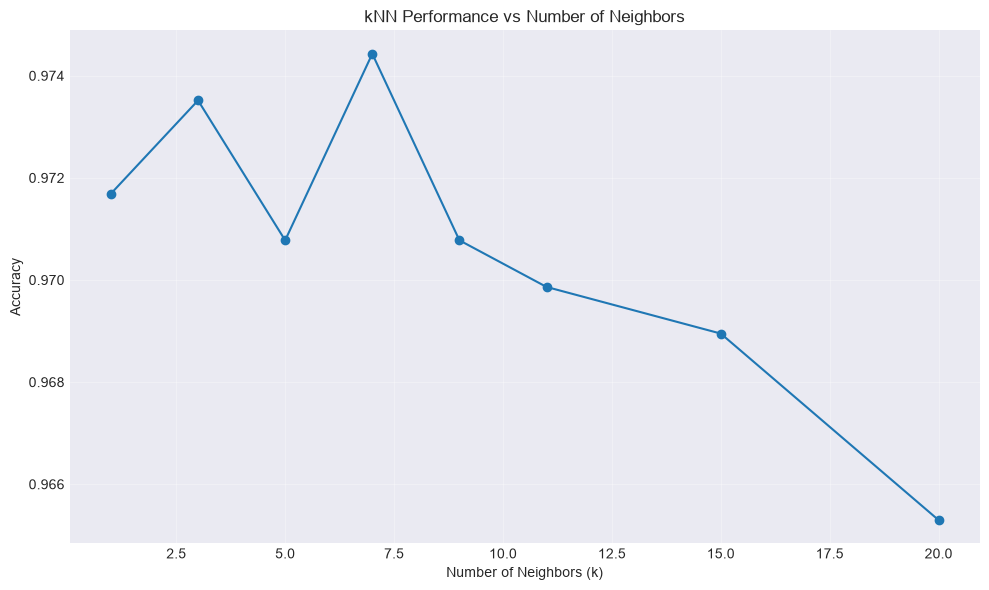

In [20]:
# Visualize k vs accuracy
plt.figure(figsize=(10, 6))
plt.plot(knn_results_df['k'], knn_results_df['accuracy'], 
         marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('kNN Performance vs Number of Neighbors')
plt.grid(alpha=0.3)
plt.tight_layout()


best_k = knn_results_df.loc[knn_results_df['accuracy'].idxmax(), 'k']
best_k_acc = knn_results_df['accuracy'].max()
print(f"\nBest k: {int(best_k)} with accuracy: {best_k_acc:.4f}")

In [21]:
# Test different distance metrics
distance_metrics = ['euclidean', 'manhattan', 'minkowski']
metric_results = []

for metric in distance_metrics:
    knn = KNeighborsClassifier(n_neighbors=int(best_k), metric=metric)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    metric_results.append({'metric': metric, 'accuracy': accuracy})
    print(f"{metric}: Accuracy = {accuracy:.4f}")

metric_results_df = pd.DataFrame(metric_results)

euclidean: Accuracy = 0.9744
manhattan: Accuracy = 0.9753
minkowski: Accuracy = 0.9744


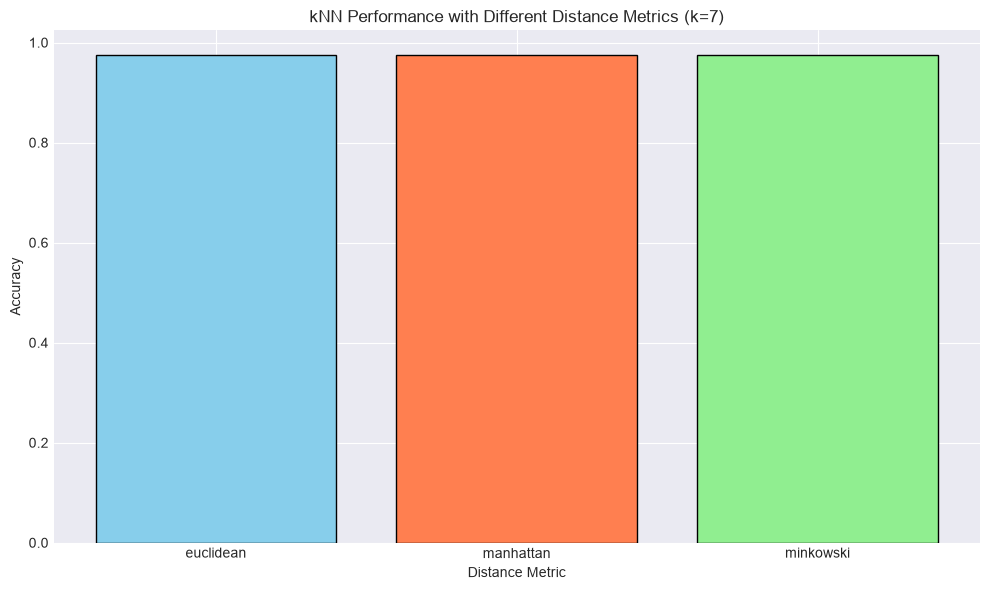

In [22]:
# Visualize metric comparison
plt.figure(figsize=(10, 6))
plt.bar(metric_results_df['metric'], metric_results_df['accuracy'], 
        color=['skyblue', 'coral', 'lightgreen'], edgecolor='black')
plt.xlabel('Distance Metric')
plt.ylabel('Accuracy')
plt.title(f'kNN Performance with Different Distance Metrics (k={int(best_k)})')
plt.tight_layout()

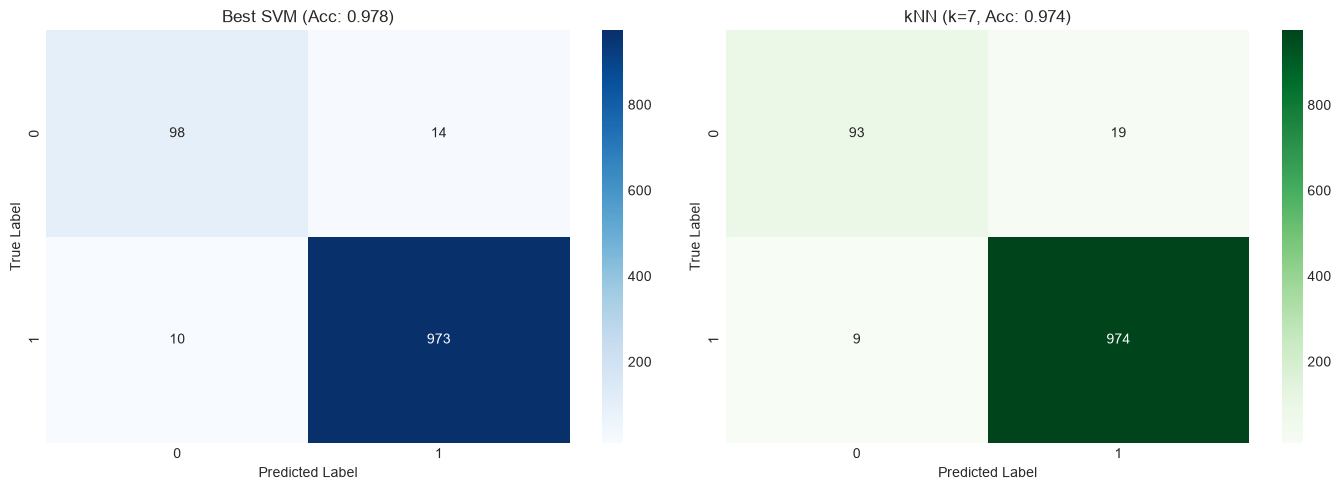

In [23]:
# Train final kNN with best parameters
knn_best = KNeighborsClassifier(n_neighbors=int(best_k))
knn_best.fit(X_train_scaled, y_train)
y_pred_knn = knn_best.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SVM
cm_svm = confusion_matrix(y_test, y_pred_best_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Best SVM (Acc: {acc_best_svm:.3f})')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# kNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'kNN (k={int(best_k)}, Acc: {acc_knn:.3f})')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()

In [24]:
# Performance comparison
comparison = pd.DataFrame({
    'Model': ['SVM Linear', 'SVM RBF', 'SVM Tuned', f'kNN (k={int(best_k)})'],
    'Accuracy': [acc_linear, acc_rbf, acc_best_svm, acc_knn],
    'F1-Score': [
        f1_score(y_test, y_pred_linear),
        f1_score(y_test, y_pred_rbf),
        f1_score(y_test, y_pred_best_svm),
        f1_score(y_test, y_pred_knn)
    ]
})

print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(comparison.to_string(index=False))
print("="*60)


MODEL PERFORMANCE COMPARISON
     Model  Accuracy  F1-Score
SVM Linear  0.965297  0.980905
   SVM RBF  0.975342  0.986343
 SVM Tuned  0.978082  0.987817
 kNN (k=7)  0.974429  0.985830
